<a href="https://colab.research.google.com/github/nobeas/Catastrophically-Forgotten/blob/main/pc_mnist_catastrophic_forgetting_Is.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Coding on MNIST + Catastrophic Forgetting (Split-MNIST)



## Step 1 — Install dependencies



In [1]:
%%capture
!pip install torch==2.3.1
!pip install torchvision==0.18.1
!git clone https://github.com/thebuckleylab/jpc.git
%cd jpc
!pip install .

## Step 2 — Imports and a quick sanity check

In [2]:
import jpc

import jax
import jax.numpy as jnp
import equinox as eqx
import equinox.nn as nn
import optax

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')  # ignore warnings

print("jpc imported OK")
print("JAX devices:", jax.devices())

/content/jpc/jpc/_core/_init.py:22: SyntaxWarning: invalid escape sequence '\{'
  $\{ f_\ell(\mathbf{z}_{\ell-1}) \}_{\ell=1}^L$ where $f_\ell(\cdot)$ is some
/content/jpc/jpc/_core/_init.py:93: SyntaxWarning: invalid escape sequence '\s'
  $z_i \sim \mathcal{N}(0, \sigma^2)$.
/content/jpc/jpc/_core/_init.py:132: SyntaxWarning: invalid escape sequence '\{'
  $\{ f_{L-\ell+1}(\mathbf{z}_{L-\ell}) \}_{\ell=1}^L$ where $\mathbf{z}_0 = \mathbf{y}$ is
/content/jpc/jpc/_core/_init.py:170: SyntaxWarning: invalid escape sequence '\{'
  """Initialises zero errors for use with ePC $\{ \epsilon_\ell = 0 \}_{l=1}^L$.
/content/jpc/jpc/_core/_grads.py:40: SyntaxWarning: invalid escape sequence '\m'
  with respect to the activities $- ∇_{\mathbf{z}} \mathcal{F}$.
/content/jpc/jpc/_core/_grads.py:110: SyntaxWarning: invalid escape sequence '\m'
  with respect to the activities $∇_{\mathbf{z}} \mathcal{F}$.
/content/jpc/jpc/_core/_grads.py:183: SyntaxWarning: invalid escape sequence '\m'
  with respect

jpc imported OK
JAX devices: [CpuDevice(id=0)]


## Step 3 — Hyperparameters

In [3]:
SEED = 0

INPUT_DIM = 784      # 28x28 flattened MNIST image
WIDTH = 300          # hidden layer width
DEPTH = 3            # number of layers
OUTPUT_DIM = 10      # 10 digit classes
ACT_FN = "relu"

LEARNING_RATE = 1e-3
BATCH_SIZE = 64
TEST_EVERY = 100
N_TRAIN_ITERS = 300

## Step 4 — MNIST dataset utilities



In [4]:
class MNIST(datasets.MNIST):
    def __init__(self, train, normalise=True, save_dir="data"):
        if normalise:
            transform = transforms.Compose(
                [
                    transforms.ToTensor(),
                    transforms.Normalize(mean=(0.1307), std=(0.3081))
                ]
            )
        else:
            transform = transforms.Compose([transforms.ToTensor()])
        super().__init__(save_dir, download=True, train=train, transform=transform)

    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        img = torch.flatten(img)
        label = one_hot(label)
        return img, label


def one_hot(labels, n_classes=10):
    arr = torch.eye(n_classes)
    return arr[labels]


def get_mnist_loaders(batch_size):
    train_data = MNIST(train=True, normalise=True)
    test_data = MNIST(train=False, normalise=True)
    train_loader = DataLoader(
        dataset=train_data, batch_size=batch_size, shuffle=True, drop_last=True
    )
    test_loader = DataLoader(
        dataset=test_data, batch_size=batch_size, shuffle=True, drop_last=True
    )
    return train_loader, test_loader

In [5]:
train_loader, test_loader = get_mnist_loaders(BATCH_SIZE)
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 4438876.49it/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 127721.93it/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:01<00:00, 1207610.54it/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 9045835.12it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw

Train batches: 937, Test batches: 156


## Step 5 — Build the PC network



In [6]:
key = jax.random.PRNGKey(SEED)

network = jpc.make_mlp(
    key,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    use_bias=True
)
print(network)

[Sequential(
  layers=(
    Lambda(fn=Identity()),
    Linear(
      weight=f32[300,784],
      bias=f32[300],
      in_features=784,
      out_features=300,
      use_bias=True
    )
  )
), Sequential(
  layers=(
    Lambda(fn=<PjitFunction of <function relu at 0x78fa969f8ae0>>),
    Linear(
      weight=f32[300,300],
      bias=f32[300],
      in_features=300,
      out_features=300,
      use_bias=True
    )
  )
), Sequential(
  layers=(
    Lambda(fn=<PjitFunction of <function relu at 0x78fa969f8ae0>>),
    Linear(
      weight=f32[10,300],
      bias=f32[10],
      in_features=300,
      out_features=10,
      use_bias=True
    )
  )
)]


## Step 6 — Train and evaluate with Predictive Coding



In [7]:
def evaluate(model, test_loader):
    # NOTE: jpc.test_discriminative_pc returns accuracy on a 0-100 scale
    # (e.g. 93.69, not 0.9369). We divide by 100 here so accuracy is always
    # a 0-1 fraction downstream -- matching the backprop baseline's scale.
    avg_test_loss, avg_test_acc = 0, 0
    for _, (img_batch, label_batch) in enumerate(test_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()
        test_loss, test_acc = jpc.test_discriminative_pc(
            model=model, input=img_batch, output=label_batch
        )
        avg_test_loss += test_loss
        avg_test_acc += test_acc / 100.0
    return avg_test_loss / len(test_loader), avg_test_acc / len(test_loader)


def train_pc(model, lr, batch_size, test_every, n_train_iters):
    optim = optax.adam(lr)
    opt_state = optim.init((eqx.filter(model, eqx.is_array), None))
    train_loader, test_loader = get_mnist_loaders(batch_size)

    for it, (img_batch, label_batch) in enumerate(train_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        result = jpc.make_pc_step(
            model=model,
            optim=optim,
            opt_state=opt_state,
            output=label_batch,
            input=img_batch
        )
        model, opt_state = result["model"], result["opt_state"]
        train_loss = result["loss"]

        if ((it + 1) % test_every) == 0:
            _, avg_test_acc = evaluate(model, test_loader)
            print(
                f"Train iter {it+1}, train loss={train_loss:.4f}, "
                f"avg test accuracy={avg_test_acc:.4f}"
            )
            if (it + 1) >= n_train_iters:
                break
    return model

## Step 7 — Let Run the plain PC classifier on full MNIST to see and check



In [8]:
network = train_pc(
    model=network,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS
)

Train iter 100, train loss=0.0873, avg test accuracy=0.9405
Train iter 200, train loss=0.0625, avg test accuracy=0.9534
Train iter 300, train loss=0.0383, avg test accuracy=0.9579


---
## Step 8 — Set up Split-MNIST for catastrophic forgetting

**Protocol (class-incremental Split-MNIST):**

- **Task A** = digits {0,1,2,3,4}
- **Task B** = digits {5,6,7,8,9}



In [9]:
TASK_A_DIGITS = [0, 1, 2, 3, 4]
TASK_B_DIGITS = [5, 6, 7, 8, 9]


def subset_by_digits(dataset, digits):
    """Return a torch Subset containing only examples whose label is in `digits`."""
    targets = dataset.targets
    if not torch.is_tensor(targets):
        targets = torch.tensor(targets)
    mask = torch.isin(targets, torch.tensor(digits))
    indices = torch.nonzero(mask, as_tuple=True)[0].tolist()
    return Subset(dataset, indices)


def get_split_mnist_loaders(batch_size):
    train_full = MNIST(train=True, normalise=True)
    test_full = MNIST(train=False, normalise=True)

    loaders = {}
    for name, digits in [("A", TASK_A_DIGITS), ("B", TASK_B_DIGITS)]:
        train_subset = subset_by_digits(train_full, digits)
        test_subset = subset_by_digits(test_full, digits)
        loaders[name] = {
            "train": DataLoader(train_subset, batch_size=batch_size, shuffle=True, drop_last=True),
            "test": DataLoader(test_subset, batch_size=batch_size, shuffle=True, drop_last=True),
        }
    return loaders

In [10]:
split_loaders = get_split_mnist_loaders(batch_size=64)
print(f"Task A: {len(split_loaders['A']['train'])} train batches, "
      f"{len(split_loaders['A']['test'])} test batches")
print(f"Task B: {len(split_loaders['B']['train'])} train batches, "
      f"{len(split_loaders['B']['test'])} test batches")

Task A: 478 train batches, 80 test batches
Task B: 459 train batches, 75 test batches


## Step 9 — Sequential training driver (PC)



In [11]:
def evaluate_all_tasks_pc(model, loaders, tasks=("A", "B")):
    accs = {}
    for name in tasks:
        _, acc = evaluate(model, loaders[name]["test"])
        accs[name] = float(acc)
    return accs


def train_task_pc(model, loaders, task_name, lr, n_iters, test_every, history):
    # Fresh optimiser state at the start of each task (see note above).
    optim = optax.adam(lr)
    opt_state = optim.init((eqx.filter(model, eqx.is_array), None))

    train_loader = loaders[task_name]["train"]
    it = 0
    while it < n_iters:
        for img_batch, label_batch in train_loader:
            img_batch, label_batch = img_batch.numpy(), label_batch.numpy()
            result = jpc.make_pc_step(
                model=model, optim=optim, opt_state=opt_state,
                output=label_batch, input=img_batch
            )
            model, opt_state = result["model"], result["opt_state"]
            it += 1

            if it % test_every == 0 or it == n_iters:
                accs = evaluate_all_tasks_pc(model, loaders)
                history["step"].append(history["_global_step"])
                history["phase"].append(task_name)
                history["acc_A"].append(accs["A"])
                history["acc_B"].append(accs["B"])
                print(f"[PC][train={task_name}] step {it}/{n_iters} "
                      f"acc_A={accs['A']:.3f} acc_B={accs['B']:.3f}")
                history["_global_step"] += test_every
            if it >= n_iters:
                break
    return model

## Step 10 — Run the PC forgetting experiment

In [12]:
CF_SEED = 1
CF_BATCH_SIZE = 64
CF_LR = 1e-3
N_ITERS_PER_TASK = 400   # iterations spent training on each task
CF_TEST_EVERY = 50

cf_key = jax.random.PRNGKey(CF_SEED)
pc_model = jpc.make_mlp(
    cf_key, input_dim=INPUT_DIM, width=WIDTH, depth=DEPTH,
    output_dim=OUTPUT_DIM, act_fn=ACT_FN, use_bias=True
)

pc_history = {"step": [], "phase": [], "acc_A": [], "acc_B": [], "_global_step": 0}

In [13]:
print("=== Phase 1: training on Task A (digits 0-4) ===")
pc_model = train_task_pc(
    pc_model, split_loaders, "A", lr=CF_LR,
    n_iters=N_ITERS_PER_TASK, test_every=CF_TEST_EVERY, history=pc_history
)

=== Phase 1: training on Task A (digits 0-4) ===
[PC][train=A] step 50/400 acc_A=0.976 acc_B=0.000
[PC][train=A] step 100/400 acc_A=0.983 acc_B=0.000
[PC][train=A] step 150/400 acc_A=0.986 acc_B=0.000
[PC][train=A] step 200/400 acc_A=0.989 acc_B=0.000
[PC][train=A] step 250/400 acc_A=0.988 acc_B=0.000
[PC][train=A] step 300/400 acc_A=0.989 acc_B=0.000
[PC][train=A] step 350/400 acc_A=0.990 acc_B=0.000
[PC][train=A] step 400/400 acc_A=0.991 acc_B=0.000


In [14]:
print("=== Phase 2: training on Task B (digits 5-9) ===")
pc_model = train_task_pc(
    pc_model, split_loaders, "B", lr=CF_LR,
    n_iters=N_ITERS_PER_TASK, test_every=CF_TEST_EVERY, history=pc_history
)

=== Phase 2: training on Task B (digits 5-9) ===
[PC][train=B] step 50/400 acc_A=0.000 acc_B=0.944
[PC][train=B] step 100/400 acc_A=0.000 acc_B=0.963
[PC][train=B] step 150/400 acc_A=0.000 acc_B=0.974
[PC][train=B] step 200/400 acc_A=0.000 acc_B=0.977
[PC][train=B] step 250/400 acc_A=0.000 acc_B=0.979
[PC][train=B] step 300/400 acc_A=0.000 acc_B=0.979
[PC][train=B] step 350/400 acc_A=0.000 acc_B=0.980
[PC][train=B] step 400/400 acc_A=0.000 acc_B=0.981


## Step 11 — Plot the PC forgetting curve

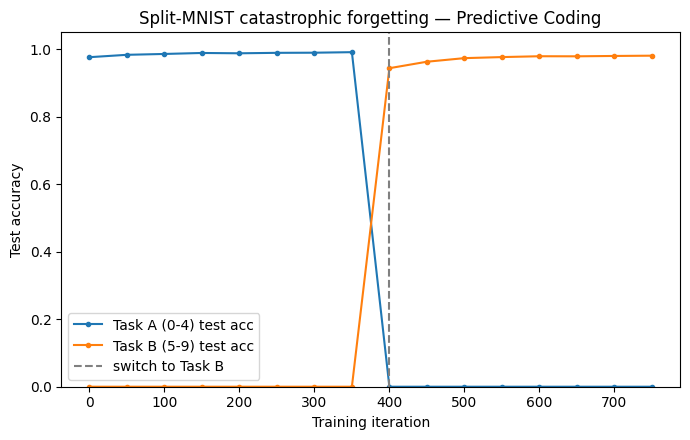

In [15]:
def plot_forgetting(history, title):
    steps = history["step"]
    switch_step = next(s for s, p in zip(history["step"], history["phase"]) if p == "B")

    plt.figure(figsize=(7, 4.5))
    plt.plot(steps, history["acc_A"], label="Task A (0-4) test acc", marker="o", ms=3)
    plt.plot(steps, history["acc_B"], label="Task B (5-9) test acc", marker="o", ms=3)
    plt.axvline(switch_step, color="grey", linestyle="--", label="switch to Task B")
    plt.xlabel("Training iteration")
    plt.ylabel("Test accuracy")
    plt.title(title)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_forgetting(pc_history, "Split-MNIST catastrophic forgetting — Predictive Coding")

---
## Step 12 — Backprop baseline: same protocol, different learning rule



In [16]:
def make_bp_mlp(key, input_dim, width, depth, output_dim):
    keys = jax.random.split(key, depth + 1)
    layers = []
    dims = [input_dim] + [width] * (depth - 1) + [output_dim]
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i + 1], key=keys[i]))
        if i < len(dims) - 2:
            layers.append(nn.Lambda(jax.nn.relu))
    return nn.Sequential(layers)


def bp_loss_fn(model, x, y):
    logits = jax.vmap(model)(x)
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    loss = -jnp.mean(jnp.sum(y * log_probs, axis=-1))
    acc = jnp.mean(jnp.argmax(logits, axis=-1) == jnp.argmax(y, axis=-1))
    return loss, acc


@eqx.filter_jit
def bp_train_step(model, optim, opt_state, x, y):
    (loss, acc), grads = eqx.filter_value_and_grad(bp_loss_fn, has_aux=True)(model, x, y)
    updates, opt_state = optim.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss, acc


@eqx.filter_jit
def bp_eval_step(model, x, y):
    _, acc = bp_loss_fn(model, x, y)
    return acc

## Step 13 — Sequential training driver (backprop)



In [17]:
def evaluate_all_tasks_bp(model, loaders, tasks=("A", "B")):
    accs = {}
    for name in tasks:
        total_acc, n_batches = 0.0, 0
        for img_batch, label_batch in loaders[name]["test"]:
            x, y = img_batch.numpy(), label_batch.numpy()
            total_acc += float(bp_eval_step(model, x, y))
            n_batches += 1
        accs[name] = total_acc / n_batches
    return accs


def train_task_bp(model, loaders, task_name, lr, n_iters, test_every, history):
    # Fresh optimiser state at the start of each task, matching train_task_pc.
    optim = optax.adam(lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_array))

    train_loader = loaders[task_name]["train"]
    it = 0
    while it < n_iters:
        for img_batch, label_batch in train_loader:
            x, y = img_batch.numpy(), label_batch.numpy()
            model, opt_state, loss, _ = bp_train_step(model, optim, opt_state, x, y)
            it += 1

            if it % test_every == 0 or it == n_iters:
                accs = evaluate_all_tasks_bp(model, loaders)
                history["step"].append(history["_global_step"])
                history["phase"].append(task_name)
                history["acc_A"].append(accs["A"])
                history["acc_B"].append(accs["B"])
                print(f"[BP][train={task_name}] step {it}/{n_iters} "
                      f"acc_A={accs['A']:.3f} acc_B={accs['B']:.3f}")
                history["_global_step"] += test_every
            if it >= n_iters:
                break
    return model

## Step 14 — Run the backprop forgetting experiment

In [18]:
bp_key = jax.random.PRNGKey(CF_SEED)
bp_model = make_bp_mlp(bp_key, INPUT_DIM, WIDTH, DEPTH, OUTPUT_DIM)

bp_history = {"step": [], "phase": [], "acc_A": [], "acc_B": [], "_global_step": 0}

In [19]:
print("=== Phase 1: training on Task A (digits 0-4) ===")
bp_model = train_task_bp(
    bp_model, split_loaders, "A", lr=CF_LR,
    n_iters=N_ITERS_PER_TASK, test_every=CF_TEST_EVERY, history=bp_history
)

=== Phase 1: training on Task A (digits 0-4) ===
[BP][train=A] step 50/400 acc_A=0.966 acc_B=0.000
[BP][train=A] step 100/400 acc_A=0.966 acc_B=0.000
[BP][train=A] step 150/400 acc_A=0.979 acc_B=0.000
[BP][train=A] step 200/400 acc_A=0.979 acc_B=0.000
[BP][train=A] step 250/400 acc_A=0.984 acc_B=0.000
[BP][train=A] step 300/400 acc_A=0.988 acc_B=0.000
[BP][train=A] step 350/400 acc_A=0.989 acc_B=0.000
[BP][train=A] step 400/400 acc_A=0.988 acc_B=0.000


In [20]:
print("=== Phase 2: training on Task B (digits 5-9) ===")
bp_model = train_task_bp(
    bp_model, split_loaders, "B", lr=CF_LR,
    n_iters=N_ITERS_PER_TASK, test_every=CF_TEST_EVERY, history=bp_history
)

=== Phase 2: training on Task B (digits 5-9) ===
[BP][train=B] step 50/400 acc_A=0.000 acc_B=0.910
[BP][train=B] step 100/400 acc_A=0.000 acc_B=0.936
[BP][train=B] step 150/400 acc_A=0.000 acc_B=0.951
[BP][train=B] step 200/400 acc_A=0.000 acc_B=0.959
[BP][train=B] step 250/400 acc_A=0.000 acc_B=0.962
[BP][train=B] step 300/400 acc_A=0.000 acc_B=0.963
[BP][train=B] step 350/400 acc_A=0.000 acc_B=0.968
[BP][train=B] step 400/400 acc_A=0.000 acc_B=0.969


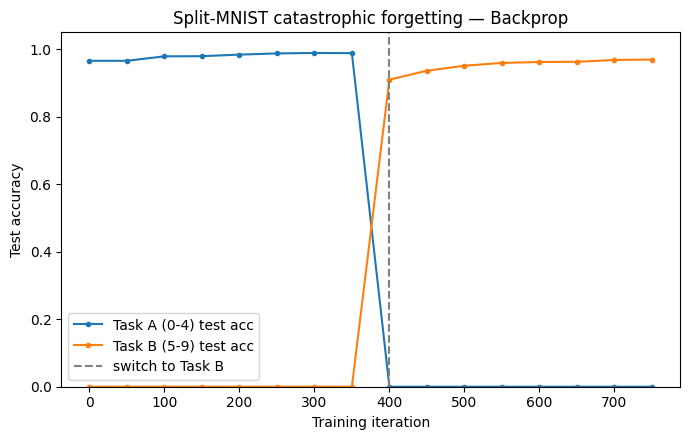

In [21]:
plot_forgetting(bp_history, "Split-MNIST catastrophic forgetting — Backprop")

---
## Step 15 — Side-by-side comparison

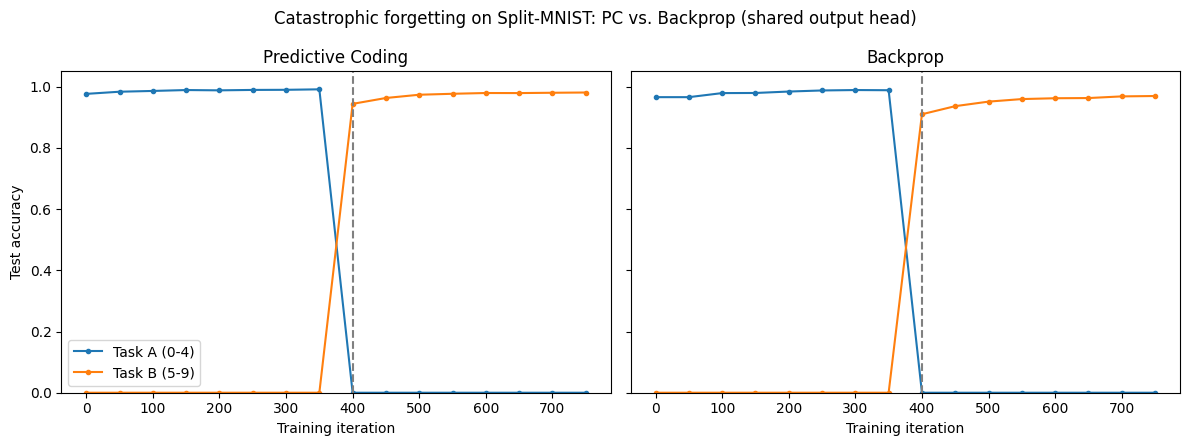

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, history, title in [
    (axes[0], pc_history, "Predictive Coding"),
    (axes[1], bp_history, "Backprop"),
]:
    steps = history["step"]
    switch_step = next(s for s, p in zip(history["step"], history["phase"]) if p == "B")
    ax.plot(steps, history["acc_A"], label="Task A (0-4)", marker="o", ms=3)
    ax.plot(steps, history["acc_B"], label="Task B (5-9)", marker="o", ms=3)
    ax.axvline(switch_step, color="grey", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Training iteration")
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("Test accuracy")
axes[0].legend()
plt.suptitle("Catastrophic forgetting on Split-MNIST: PC vs. Backprop (shared output head)")
plt.tight_layout()
plt.show()

In [23]:
def forgetting_amount(history):
    phase_a_idx = [i for i, p in enumerate(history["phase"]) if p == "A"]
    phase_b_idx = [i for i, p in enumerate(history["phase"]) if p == "B"]
    acc_a_end_of_phase1 = history["acc_A"][phase_a_idx[-1]]
    acc_a_end_of_phase2 = history["acc_A"][phase_b_idx[-1]]
    return acc_a_end_of_phase1, acc_a_end_of_phase2, acc_a_end_of_phase1 - acc_a_end_of_phase2


for name, history in [("PC", pc_history), ("Backprop", bp_history)]:
    before, after, drop = forgetting_amount(history)
    print(f"{name}: Task A acc before Task B training = {before:.3f}, "
          f"after = {after:.3f}  ->  forgetting = {drop:.3f}")

PC: Task A acc before Task B training = 0.991, after = 0.000  ->  forgetting = 0.991
Backprop: Task A acc before Task B training = 0.988, after = 0.000  ->  forgetting = 0.988
